# Shallow Neural Network

### Feature Engineering

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('vehicle_maintenance_data.csv')
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,11/23/2023,6/24/2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,9/21/2023,6/4/2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,6/27/2023,4/27/2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,8/24/2023,11/5/2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,5/25/2023,9/14/2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [31]:
df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'])

In [32]:
df[['Service_History', 'Accident_History', 'Reported_Issues']]
df['Hist_Record'] = (df['Service_History'] + df['Accident_History'] + df['Reported_Issues']) /  3

df_updated = df.copy()

df_updated.drop(columns= ['Service_History', 'Accident_History', 'Reported_Issues'], axis= 1, inplace= True)

df_updated.head()

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,Truck,58765,Good,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,13.622204,New,New,Weak,1,3.000000
1,Van,60353,Average,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,13.625307,New,New,Weak,1,2.666667
2,Bus,68072,Poor,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,14.306302,New,Good,Weak,1,2.333333
3,Bus,60849,Average,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,18.709467,New,Worn Out,New,1,4.666667
4,Bus,45742,Poor,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,16.977483,Good,Good,Weak,1,4.333333


In [33]:
object_col = []

for i in df_updated.columns:
    if df[i].dtype == 'object':
        object_col.append(i)

encoder = LabelEncoder()

for encoded in object_col:
    df_updated[encoded] = encoder.fit_transform(df_updated[encoded])

df_updated

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,1,2,1,3.000000
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,1,2,1,2.666667
2,0,68072,2,2,1,0,1500,34022,2023-06-27,2025-04-27,0,17979,14.306302,1,0,2,1,2.333333
3,0,60849,0,5,2,0,2500,81636,2023-08-24,2025-11-05,1,6220,18.709467,1,2,1,1,4.666667
4,0,45742,2,1,2,1,2000,97162,2023-05-25,2025-09-14,2,16446,16.977483,0,0,2,1,4.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1,77229,1,6,0,0,2500,97404,2023-11-24,2025-09-15,2,5217,10.357298,1,0,2,1,2.666667
49996,4,54742,1,4,0,1,800,13421,2023-07-14,2025-01-21,1,15856,14.924022,2,1,0,1,3.000000
49997,5,75601,2,4,1,0,1500,124851,2023-09-09,2024-11-09,0,6019,19.859243,2,2,2,1,3.333333
49998,1,66181,1,7,1,1,2500,103182,2023-08-26,2025-05-22,2,5030,10.720555,1,0,2,1,2.666667


In [34]:
df_updated['service_status'] = df_updated['Tire_Condition'] + df_updated['Brake_Condition'] + df_updated['Battery_Status'] / 3

df_updated.drop(columns=['Tire_Condition', 'Brake_Condition', 'Battery_Status'], inplace= True, axis = 1)

df_updated.head(2)

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,3.000000,2.666667
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,2.666667,2.666667


In [35]:
df_updated['miles_per_year'] = df_updated['Mileage'] / df['Vehicle_Age']

df_updated.drop(columns=['Mileage', 'Vehicle_Age'], inplace= True, axis= 1)

df_updated.describe()

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status,miles_per_year
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.503700,0.996800,0.99884,0.500180,1556.292000,75551.187060,2023-09-13 10:33:48.096000,2025-04-11 15:56:30.336000256,1.002700,17465.340700,14.990323,0.809960,3.171513,2.335213,16135.339941
min,0.000000,0.000000,0.00000,0.000000,800.000000,1001.000000,2023-03-30 00:00:00,2024-04-28 00:00:00,0.000000,5000.000000,10.000098,0.000000,0.333333,0.000000,3000.500000
25%,1.000000,0.000000,0.00000,0.000000,1000.000000,38009.000000,2023-06-21 00:00:00,2024-10-18 00:00:00,0.000000,11189.750000,12.489037,1.000000,2.333333,1.333333,6780.325000
50%,3.000000,1.000000,1.00000,1.000000,1500.000000,75598.500000,2023-09-14 00:00:00,2025-04-12 00:00:00,1.000000,17477.500000,14.986352,1.000000,3.333333,2.333333,10030.166667
75%,4.000000,2.000000,2.00000,1.000000,2000.000000,112999.500000,2023-12-06 00:00:00,2025-10-04 00:00:00,2.000000,23692.000000,17.474676,1.000000,4.000000,3.333333,18389.500000
max,5.000000,2.000000,2.00000,1.000000,2500.000000,149999.000000,2024-02-28 00:00:00,2026-03-29 00:00:00,2.000000,30000.000000,19.999968,1.000000,6.000000,4.666667,79990.000000
std,1.711422,0.815943,0.81754,0.500005,627.677218,43088.105658,NaN,NaN,0.813945,7223.393401,2.885583,0.392336,1.176649,1.186846,15588.301259


In [36]:
df_updated['total_hist_service'] = df_updated['Hist_Record'] + df_updated['service_status'] / 2 

df_updated.drop(columns=['Hist_Record', 'service_status'], inplace= True, axis= 1)

In [37]:
df_updated['last_Service_month'] = df_updated['Last_Service_Date'].dt.month
df_updated['Last_Service_Date'].dt.dayofweek.value_counts()

df_updated['week_number'] = df_updated['Last_Service_Date'].dt.isocalendar().week
df_updated.drop(columns=['Last_Service_Date', 'Warranty_Expiry_Date'], axis= 1, inplace= True)

df_updated.head(3)

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,miles_per_year,total_hist_service,last_Service_month,week_number
0,4,1,1,0,2000,28524,1,20782,13.622204,1,14691.250000,4.333333,11,47
1,5,0,1,0,2500,133630,1,23489,13.625307,1,8621.857143,4.000000,9,38
2,0,2,1,0,1500,34022,0,17979,14.306302,1,34036.000000,3.166667,6,26


### Modeling


In [57]:
!pip install imbalanced-learn --quiet

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [46]:
X = df_updated.drop(columns='Need_Maintenance', axis = 1)
y = df_updated['Need_Maintenance']

x_train, x_test, y_train, y_test = train_test_split(X,y,train_size= .6, shuffle= True, stratify= y , random_state= 42)

In [47]:
x_train.head(2)

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Fuel_Efficiency,miles_per_year,total_hist_service,last_Service_month,week_number
47669,3,0,1,0,2500,111600,0,11192,19.338884,9733.75,5.166667,1,3
1232,1,0,2,1,2500,101025,1,20481,16.951915,21039.00,5.000000,1,1


In [48]:
non_binary_col = []
for i in x_train.columns:
    if x_train[i].nunique() != 2:
        non_binary_col.append(i)
print(non_binary_col)

['Vehicle_Model', 'Maintenance_History', 'Fuel_Type', 'Engine_Size', 'Odometer_Reading', 'Owner_Type', 'Insurance_Premium', 'Fuel_Efficiency', 'miles_per_year', 'total_hist_service', 'last_Service_month', 'week_number']


In [49]:
binary_col = []
for i in x_train.columns:
    if x_train[i].nunique() == 2:
        binary_col.append(i)
print(binary_col)

['Transmission_Type']


In [52]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train[non_binary_col])
x_test_scaled =  scaler.transform(x_test[non_binary_col])

x_train_scaled

array([[ 0.29127022, -1.22675892,  0.0035892 , ...,  0.63084447,
        -1.70786307, -1.67069747],
       [-0.87856799, -1.22675892,  1.2271801 , ...,  0.50381517,
        -1.70786307, -1.80532311],
       [ 1.46110842, -1.22675892,  1.2271801 , ..., -0.63944859,
        -1.70786307, -1.67069747],
       ...,
       [-1.46348709, -0.00265223, -1.2200017 , ...,  0.50381517,
        -0.53723859, -0.59369234],
       [ 0.29127022,  1.22145446,  0.0035892 , ..., -1.27459512,
        -0.53723859, -0.59369234],
       [-0.87856799,  1.22145446,  1.2271801 , ..., -1.02053651,
         0.34072977,  0.34868714]])

In [60]:
binary_features = x_train[binary_col].astype(float).values

In [61]:
x_train_full = np.concatenate([x_train_scaled, binary_features], axis=1)

In [62]:
smote = SMOTE(random_state=42)
x_train_balance, y_train_balanced = smote.fit_resample(x_train_full, y_train)

In [63]:
# prep the test the same way
binary_features_test = x_test[binary_col].astype(float).values
x_test_full = np.concatenate([x_test_scaled, binary_features_test], axis=1)


In [64]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(16, activation='relu', input_shape=(x_train_balance.shape[1],)),
    Dense(1, activation='sigmoid')  # binary output
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_balance, y_train_balanced,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2)

test_loss, test_acc = model.evaluate(x_test_full, y_test)
print(f'Test accuracy: {test_acc:.4f}')


2025-05-28 08:02:06.488915: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6767 - loss: 0.5760 - val_accuracy: 0.6285 - val_loss: 0.6979
Epoch 2/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7195 - loss: 0.5192 - val_accuracy: 0.6212 - val_loss: 0.7009
Epoch 3/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7239 - loss: 0.5116 - val_accuracy: 0.5945 - val_loss: 0.7255
Epoch 4/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7248 - loss: 0.5031 - val_accuracy: 0.6131 - val_loss: 0.7072
Epoch 5/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7284 - loss: 0.5024 - val_accuracy: 0.6186 - val_loss: 0.7019
Epoch 6/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7288 - loss: 0.5039 - val_accuracy: 0.6391 - val_loss: 0.6800
Epoch 7/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7276 - loss: 0.5024 - val_accuracy: 0.6280 - val_loss: 0.6959
Epoch 8/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7331 - loss: 0.5003 - 

In [65]:
# Predict probabilities on test data
y_pred_probs = model.predict(x_test_full)

# Convert probabilities to class labels
pred = (y_pred_probs >= 0.5).astype(int).flatten()


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step


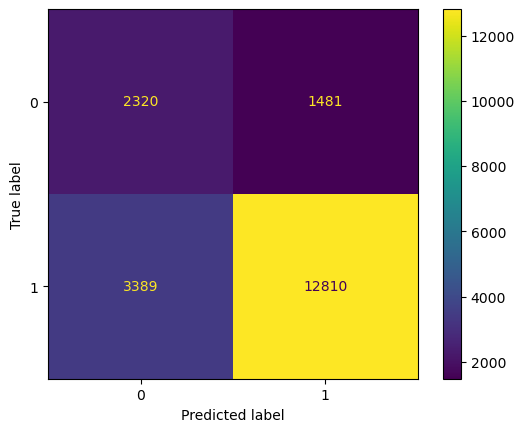

              precision    recall  f1-score   support

           0       0.41      0.61      0.49      3801
           1       0.90      0.79      0.84     16199

    accuracy                           0.76     20000
   macro avg       0.65      0.70      0.66     20000
weighted avg       0.80      0.76      0.77     20000



In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Classification report
print(classification_report(y_test, pred))
